# Features analysis code

## Requirements

In [1]:
 !pip3 install pandas openpyxl scipy numpy statsmodels matplotlib seaborn scikit-learn ollama

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Imports

In [2]:
import pandas as pd
import openpyxl
import scipy
import numpy as np
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import LeaveOneGroupOut, permutation_test_score
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import os
os.environ["OLLAMA_HOST"] = os.getenv("OLLAMA_HOST")
import ollama

## Dataframe import

In [3]:
features_df = pd.read_excel("../extracted_features/extracted_features_final.xlsx")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

## Demographics

In [4]:
# For the computation on demographics
participants_df = features_df.drop_duplicates("participant_id")

### Gender

In [5]:
gender_percent = participants_df["gender"].value_counts(normalize=True) * 100

print(gender_percent)

gender
F    52.0
M    48.0
Name: proportion, dtype: float64


### Age

In [6]:
age_mean = participants_df["age"].mean()
age_std = participants_df["age"].std()
age_min = participants_df["age"].min()
age_max = participants_df["age"].max()

print(f"Mean age = {age_mean:.2f}")
print(f"SD age = {age_std:.2f}")
print(f"Range = {age_min}–{age_max}")

Mean age = 24.52
SD age = 4.93
Range = 18–36


## Manipulation check

In [7]:
# Helper function
def paired_test(df, variable, alternative, alpha=0.05):
    
    df_paired = df.pivot(
        index="participant_id",
        columns="condition",
        values=variable
    )
    
    diff = df_paired[2] - df_paired[1]   # condition 2 minus condition 1

    mean_c1 = np.mean(df_paired[1])
    mean_c2 = np.mean(df_paired[2])
    mean_diff = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)
    
    # Cohen's dz
    cohens_dz = mean_diff / sd_diff if sd_diff != 0 else np.nan

    # 95% CI for mean difference
    n = len(diff)
    se_diff = sd_diff / np.sqrt(n)
    t_crit = scipy.stats.t.ppf(0.975, df=n-1)
    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff
    
    # Normality test
    shapiro_stat, shapiro_p = scipy.stats.shapiro(diff)
    
    print(f"\n=== {variable} ===")
    print(f"Mean C1 = {mean_c1:.3f}")
    print(f"Mean C2 = {mean_c2:.3f}")
    print(f"Mean difference (C2 - C1) = {mean_diff:.3f}")
    print(f"95% CI of difference = [{ci_low:.3f}, {ci_high:.3f}]")
    print(f"Cohen's dz = {cohens_dz:.3f}")
    print(f"Shapiro p = {shapiro_p:.4f}")
    
    if shapiro_p > alpha:
        print("Normality met → Paired t-test")
        stat, p = scipy.stats.ttest_rel(df_paired[2], df_paired[1], alternative=alternative)
    else:
        print("Normality violated → Wilcoxon test")
        stat, p = scipy.stats.wilcoxon(df_paired[2], df_paired[1], alternative=alternative)

    print(f"Test statistic = {stat:.3f}")
    print(f"p-value = {p:.4f}")
    
    if p < alpha:
        print(f"Conclusion: {variable} is significantly higher in Condition 2 than in Condition 1.")
    else:
        print(f"Conclusion: There is no statistically significant evidence that {variable} is higher in Condition 2 than in Condition 1.")

In [8]:
paired_test(features_df, "perceived_topic_intimacy", "greater")
paired_test(features_df, "personal_discomfort", "greater")
paired_test(features_df, "revealing_personal_information", "greater")


=== perceived_topic_intimacy ===
Mean C1 = 2.840
Mean C2 = 3.680
Mean difference (C2 - C1) = 0.840
95% CI of difference = [0.118, 1.562]
Cohen's dz = 0.480
Shapiro p = 0.0086
Normality violated → Wilcoxon test
Test statistic = 227.500
p-value = 0.0122
Conclusion: perceived_topic_intimacy is significantly higher in Condition 2 than in Condition 1.

=== personal_discomfort ===
Mean C1 = 1.257
Mean C2 = 1.903
Mean difference (C2 - C1) = 0.646
95% CI of difference = [0.329, 0.963]
Cohen's dz = 0.842
Shapiro p = 0.2384
Normality met → Paired t-test
Test statistic = 4.210
p-value = 0.0002
Conclusion: personal_discomfort is significantly higher in Condition 2 than in Condition 1.

=== revealing_personal_information ===
Mean C1 = 1.790
Mean C2 = 2.660
Mean difference (C2 - C1) = 0.870
95% CI of difference = [0.522, 1.218]
Cohen's dz = 1.033
Shapiro p = 0.0095
Normality violated → Wilcoxon test
Test statistic = 220.000
p-value = 0.0001
Conclusion: revealing_personal_information is significantl

## Statistics on extracted features

In [9]:
# Helper function
def paired_test(df, variable, alternative="two-sided", alpha=0.05):

    df_paired = df.pivot(
        index="participant_id",
        columns="condition",
        values=variable
    )
    
    diff = df_paired[2] - df_paired[1]
    
    # Normality test
    shapiro_stat, shapiro_p = scipy.stats.shapiro(diff)
    
    # Effect size: Cohen's dz (always computed)
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    cohens_dz = mean_diff / std_diff if std_diff != 0 else np.nan
    
    if shapiro_p > alpha:
        test_used = "paired_t"
        stat, p = scipy.stats.ttest_rel(df_paired[2], df_paired[1], alternative=alternative)
        wilcoxon_r = np.nan
        
    else:
        test_used = "wilcoxon"
        stat, p = scipy.stats.wilcoxon(df_paired[2], df_paired[1], alternative=alternative)
        
        # Wilcoxon effect size r
        diff_nonzero = diff[diff != 0]
        n = len(diff_nonzero)
        mean_w = n * (n + 1) / 4
        sd_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
        z = (stat - mean_w) / sd_w if sd_w != 0 else np.nan
        wilcoxon_r = z / np.sqrt(n) if n != 0 else np.nan
    
    return {"feature": variable,
            "shapiro_p": shapiro_p,
            "test_used": test_used,
            "statistic": stat,
            "p_value": p,
            "cohens_dz": cohens_dz,
            "wilcoxon_r": wilcoxon_r,
            "mean_diff_c2_minus_c1": mean_diff}

In [10]:
# Run test on all behavioral features
exclude_columns = ["participant_id", "condition", "gender", "age", "perceived_topic_intimacy", "personal_discomfort", "revealing_personal_information"]
feature_columns = [col for col in features_df.columns if col not in exclude_columns]

results = []

for feature in feature_columns:
    result = paired_test(features_df, feature, alternative="two-sided")
    results.append(result)

results_df = pd.DataFrame(results)

In [11]:
# Apply FDR Correction (False Discovery Rate, Benjamini–Hochberg)
reject, pvals_corrected, _, _ = multipletests(results_df["p_value"], alpha=0.05, method="fdr_bh")

results_df["p_fdr"] = pvals_corrected
results_df["significant_fdr"] = reject
results_df = results_df.sort_values("p_fdr")
results_df["direction"] = np.where(results_df["mean_diff_c2_minus_c1"] > 0, "higher_in_c2", "lower_in_c2")

results_df

,feature,shapiro_p,test_used,statistic,p_value,cohens_dz,wilcoxon_r,mean_diff_c2_minus_c1,p_fdr,significant_fdr,direction
62,mean_disclosure_depth,6.818764e-01,paired_t,3.936611,0.000618,0.787322,NaN,3.901794e-01,0.038956,True,higher_in_c2
46,drawing_VLM_intimacy_score,1.333830e-01,paired_t,3.239320,0.003491,0.647864,NaN,4.533333e-01,0.109979,False,higher_in_c2
2,stroke_total_length,1.289390e-03,wilcoxon,73.000000,0.014722,-0.354566,-0.481634,-1.243038e+04,0.231872,False,lower_in_c2
42,drawing_nature_animals_presence,1.428715e-05,wilcoxon,5.500000,0.011412,-0.574737,-0.709124,-3.200000e-01,0.231872,False,lower_in_c2
1,total_stroke_count,6.855939e-01,paired_t,-2.147701,0.042045,-0.429540,NaN,-3.220000e+01,0.529771,False,lower_in_c2
43,drawing_emotional_symbols_presence,4.662209e-05,wilcoxon,11.000000,0.057780,0.401865,-0.531843,2.400000e-01,0.594402,False,higher_in_c2
27,pixel_std_y,1.785100e-03,wilcoxon,96.000000,0.075480,-0.370143,-0.357862,-1.704171e-02,0.594402,False,lower_in_c2
21,stroke_frequency,3.222712e-01,paired_t,-1.882970,0.071881,-0.376594,NaN,-3.563084e-02,0.594402,False,lower_in_c2
16,stroke_mean_angularity,9.060367e-01,paired_t,1.157542,0.258442,0.231508,NaN,2.188179e-02,0.665503,False,higher_in_c2
17,avg_time_between_strokes,3.924101e-01,paired_t,1.566297,0.130371,0.313259,NaN,5.908632e-01,0.665503,False,higher_in_c2


## Correlation analysis

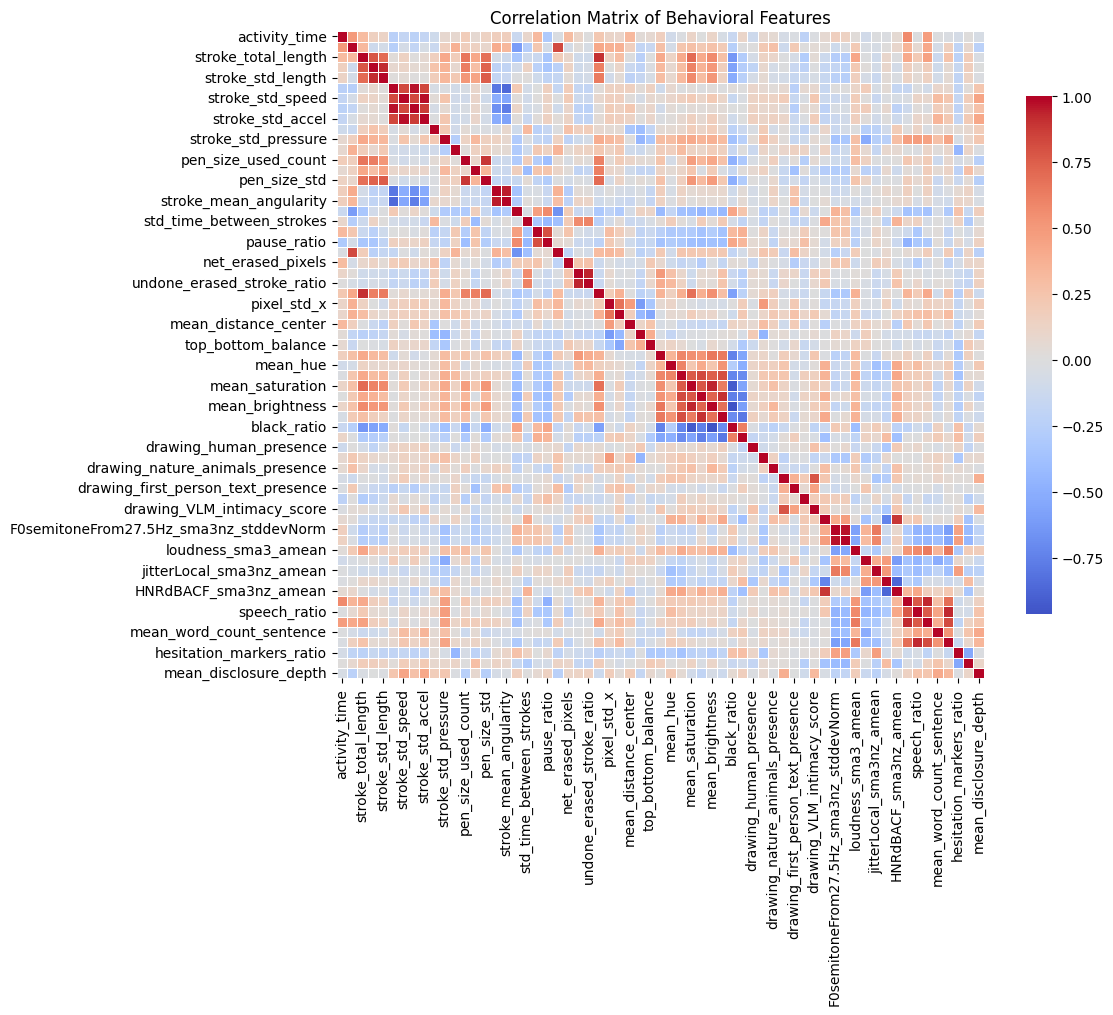

In [12]:
exclude_columns = ["participant_id", "condition", "gender", "age", "perceived_topic_intimacy", "personal_discomfort", "revealing_personal_information"]

# Select behavioral features only
behavioral_df = features_df.drop(columns=exclude_columns, errors="ignore")

corr_matrix = behavioral_df.corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Behavioral Features")
plt.savefig("correlation_matrix_full_set_300_dpi.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [13]:
# Find high correlations
high_corr_pairs = []

threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, value))

# Print results
print("\nHighly correlated feature pairs (|r| > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]}  <->  {pair[1]}  : r = {pair[2]:.3f}")


Highly correlated feature pairs (|r| > 0.85):
stroke_std_length  <->  stroke_mean_length  : r = 0.916
stroke_mean_accel  <->  stroke_mean_speed  : r = 0.964
stroke_std_accel  <->  stroke_std_speed  : r = 0.969
stroke_std_accel  <->  stroke_mean_accel  : r = 0.875
pen_size_std  <->  pen_size_used_count  : r = 0.889
stroke_mean_angularity  <->  stroke_mean_speed  : r = -0.856
stroke_mean_angularity  <->  stroke_mean_curvature  : r = 0.953
undone_erased_stroke_ratio  <->  undone_erased_stroke_count  : r = 0.936
surface_coverage_ratio  <->  stroke_total_length  : r = 0.901
mean_brightness  <->  mean_saturation  : r = 0.933
std_brightness  <->  std_saturation  : r = 0.902
black_ratio  <->  mean_saturation  : r = -0.928
black_ratio  <->  mean_brightness  : r = -0.962
F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2  <->  F0semitoneFrom27.5Hz_sma3nz_stddevNorm  : r = 0.969
HNRdBACF_sma3nz_amean  <->  F0semitoneFrom27.5Hz_sma3nz_amean  : r = 0.888
HNRdBACF_sma3nz_amean  <->  shimmerLocaldB_sma3nz_ame

## ML classifier (highly correlated features removed)

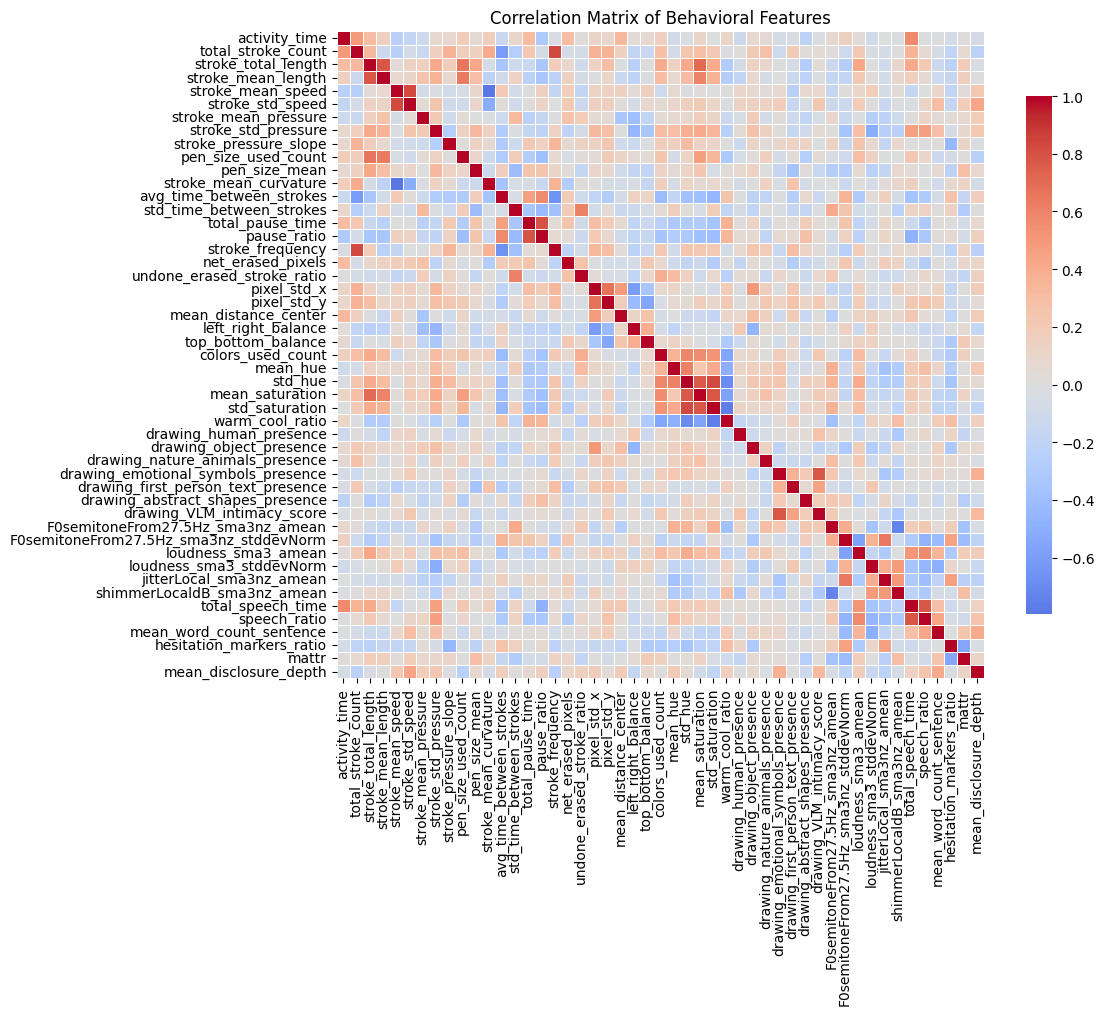

In [14]:
exclude_columns = ["participant_id", 
                   "condition", 
                   "gender", 
                   "age", 
                   "perceived_topic_intimacy", 
                   "personal_discomfort", 
                   "revealing_personal_information",
                   "stroke_std_length",
                   "stroke_mean_accel",
                   "stroke_std_accel",
                   "pen_size_std",
                   "stroke_mean_angularity",
                   "undone_erased_stroke_count",
                   "surface_coverage_ratio",
                   "mean_brightness",
                   "std_brightness",
                   "black_ratio",
                   "F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2",
                   "HNRdBACF_sma3nz_amean",
                   "word_count",
                   "word_count_per_sec"
                   ]

# Select behavioral features only
behavioral_df = features_df.drop(columns=exclude_columns, errors="ignore")

corr_matrix = behavioral_df.corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Behavioral Features")
plt.savefig("correlation_matrix_reduced_set_300_dpi.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [15]:
# Prepare data
X = features_df.drop(columns=exclude_columns, errors="ignore")
X = X.select_dtypes(include=[np.number])

y = features_df["condition"]  # 1 or 2
y = (y == 2).astype(int) # Convert condition to 0/1

groups = features_df["participant_id"]

In [16]:
# Define classifiers
classifiers = {
    "LogisticRegression": LogisticRegression(
        solver="liblinear",
        max_iter=1000
    ),

    "LinearSVM": SVC(
        kernel="linear",
        probability=True,   # needed for ROC-AUC
    ),

    "NaiveBayes": GaussianNB()
}

In [17]:
# Define Validation method
# Leave-One-Group-Out Cross Validation (LOGO CV)
# -> train on n-1 participants, test on 1 participant, repeat n times. Group = 1 participant with 2 conditions
logo = LeaveOneGroupOut()


LogisticRegression
Confusion Matrix:
[[18  7]
 [ 7 18]]
Accuracy: 0.720
ROC-AUC: 0.824
Permutation p-value: 0.0040


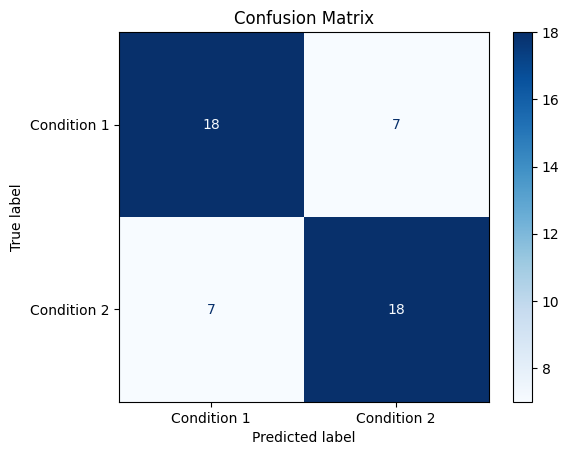

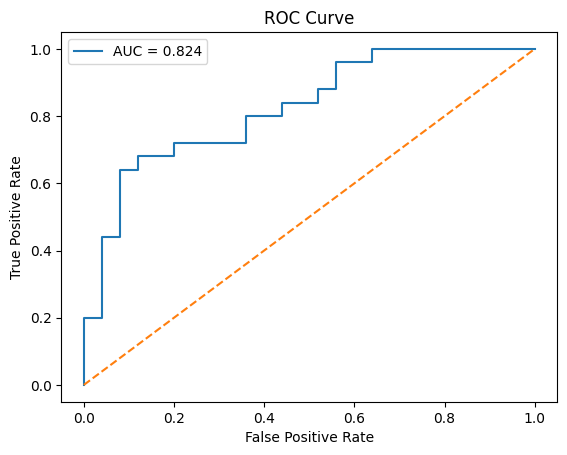


LinearSVM
Confusion Matrix:
[[21  4]
 [ 8 17]]
Accuracy: 0.760
ROC-AUC: 0.834
Permutation p-value: 0.0010


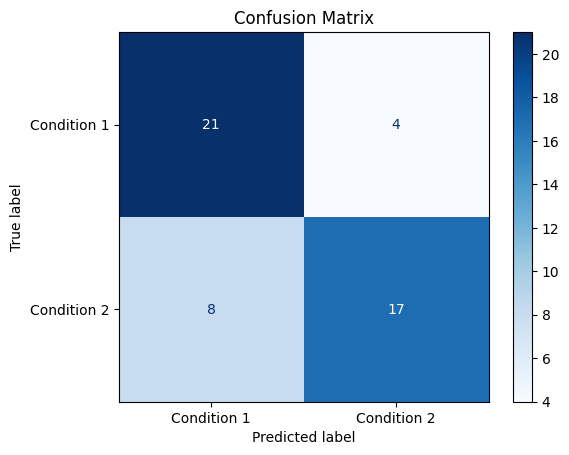

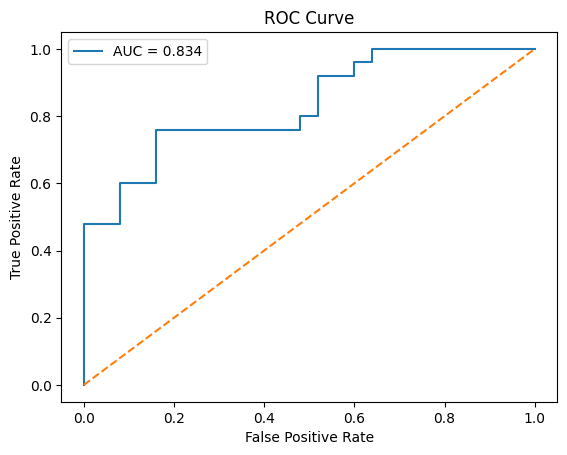


NaiveBayes
Confusion Matrix:
[[14 11]
 [12 13]]
Accuracy: 0.540
ROC-AUC: 0.592
Permutation p-value: 0.3536


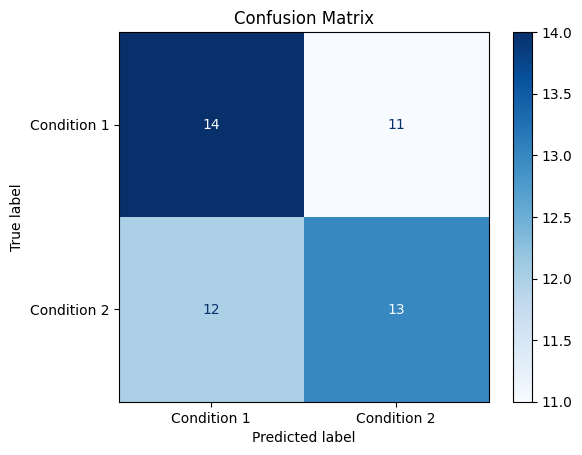

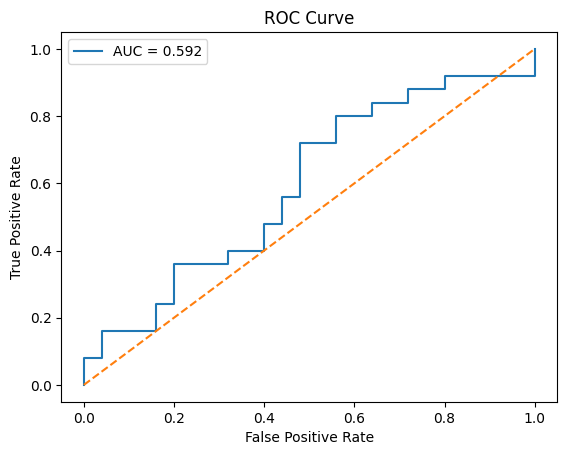


=== Classifier Comparison ===
           Classifier  Accuracy  ROC_AUC  Permutation_p
1           LinearSVM      0.76   0.8336       0.000999
0  LogisticRegression      0.72   0.8240       0.003996
2          NaiveBayes      0.54   0.5920       0.353646

=== Feature Importance (LogisticRegression) ===
                            feature  importance_mean  importance_std
32  drawing_nature_animals_presence             0.08        0.153623
36       drawing_VLM_intimacy_score             0.08        0.153623
48            mean_disclosure_depth             0.08        0.153623
16                 stroke_frequency             0.03        0.081240
8             stroke_pressure_slope             0.03        0.081240
22               left_right_balance             0.02        0.120830
11            stroke_mean_curvature             0.01        0.149666
3                stroke_mean_length             0.01        0.048990
2               stroke_total_length             0.01        0.048990
41    

In [18]:
# Loop over the classifiers
results = []
all_importances = {}
for name, clf in classifiers.items():

    # Setup Pipeline and standardizer
    pipeline = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    
    y_true = []
    y_pred = []
    y_proba = []

    fold_importances = []
    
    # Train and test
    for train_idx, test_idx in logo.split(X, y, groups):
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        pipeline.fit(X_train, y_train)
        
        preds = pipeline.predict(X_test)
        probas = pipeline.predict_proba(X_test)[:, 1]
        
        y_true.extend(y_test)
        y_pred.extend(preds)
        y_proba.extend(probas)

        # --- permutation importance on test fold ---
        result = permutation_importance(
            pipeline,
            X_test,
            y_test,
            n_repeats=50,
            random_state=42,
            scoring="accuracy"
        )

        fold_importances.append(result.importances_mean)

    fold_importances = np.array(fold_importances)
    all_importances[name] = fold_importances

    # Performance metrics
    # Confusion matrix
    # [[TN  FP]
    # [FN  TP]]
    # The ROC curve is the plot of the true positive rate (TPR = TP/P) against the false positive rate (FPR = FP/N) at each threshold setting.
    # Variation of the probability threshold distinguishing if a prediction is of one class or the other 
    acc = accuracy_score(y_true, y_pred)
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    cm = confusion_matrix(y_true, y_pred)

    # Permutation test (how much the model is better than random chance)
    # Allows to say if the obtained accuracy when training with the real data is better than when trained with randomized output
    score, perm_scores, pvalue = permutation_test_score(
        pipeline,
        X,
        y,
        groups=groups,
        cv=logo,
        scoring="accuracy",
        n_permutations=1000,
        n_jobs=-1)

    results.append({"Classifier": name, "Accuracy": acc, "ROC_AUC": roc_auc, "Permutation_p": pvalue})

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy: {acc:.3f}")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Permutation p-value: {pvalue:.4f}")

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Condition 1", "Condition 2"], cmap="Blues")

    plt.title("Confusion Matrix")
    fig_name_matrix = "confusion_matrix_" + name + "_correlated_features_removed_300_dpi.png"
    plt.savefig(fig_name_matrix, dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

    fig_name_roc = "roc_curve_" + name + "_correlated_features_removed_300_dpi.png"
    plt.savefig(fig_name_roc, dpi=300, bbox_inches="tight")
    plt.show()


# Summary table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Accuracy", ascending=False)

print("\n=== Classifier Comparison ===")
print(results_df)



importance_tables = {}

for name in classifiers.keys():

    importances = all_importances[name]

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": importances.mean(axis=0),
        "importance_std": importances.std(axis=0)
    })

    importance_df = importance_df.sort_values(
        "importance_mean",
        ascending=False
    )

    importance_tables[name] = importance_df

    print(f"\n=== Feature Importance ({name}) ===")
    print(importance_df.head(10))

## Thematic analysis (post questionnaire open feedback)

In [19]:
VLM_PROMPT_OPEN_FEEDBACK = """
You are assisting with qualitative research analysis.

Your task is to conduct a thematic analysis of participant feedback comments.
The goal is to identify the main recurring themes in the feedback.

Follow these steps:

1. Carefully read all participant comments.
2. Identify recurring ideas, concerns, or experiences mentioned by participants.
3. Group similar ideas into broader themes.
4. Provide clear and concise theme names.
5. For each theme, give a short description explaining the theme.

Guidelines:
- Themes should represent patterns across multiple participants when possible.
- Themes should be conceptually meaningful, not just keywords.
- Avoid creating too many themes; aim for approximately 3–8 themes.
- If some comments do not fit into any major theme, place them in a category called "Other observations".

Output format:

Theme 1: [Theme name]
Description: [short explanation]

Theme 2: [Theme name]
Description: ...
"""

In [20]:
# Extract open feedback summary
open_feedback_file_path = "../data/open_feedback.txt"
with open(open_feedback_file_path, "r") as file:
    text = file.read()

conversation_history = [{"role": "system", "content": VLM_PROMPT_OPEN_FEEDBACK}, 
                        {"role": "user", "content": text}]

vlm_output = ollama.chat(model="qwen3-vl:235b-a22b-instruct", messages=conversation_history)
vlm_reply = vlm_output["message"]["content"]

print(vlm_reply)

Here is a thematic analysis of the participant feedback, identifying recurring patterns and key insights:

---

**Theme 1: Speech Recognition & Turn-Taking Issues**  
*Description:* Multiple participants (p6, p7, p9, p11, p12, p14, p18, p20, p22, p23, p25, p26, p30, p32) reported that the robot’s speech recognition system was too sensitive, often cutting off human speech before completion. This caused frustration and a feeling of being interrupted, disrupting natural conversation flow.

---

**Theme 2: Robot’s Questioning Style – Helpful Yet Repetitive or Overwhelming**  
*Description:* While some participants appreciated the robot’s follow-up questions for keeping conversation flowing (p12, p20, p30, p31), others found them intrusive (p11), repetitive (p25, p31), or too similar (p25), leading to a sense of not being heard. Some also noted that questions sometimes led conversations off-topic (p20, p29, p28).

---

**Theme 3: User Interface & Visual Feedback Clarity**  
*Description:* S